In [1]:
# ── Standard library ────────────────────────────────────────────
import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets
import re          # Regular expression operations
import json        # Functions for working with JSON data (parse, serialize)
import pprint      # Pretty print JSON

# ── Numerical computing ─────────────────────────────────────────
import numpy as np  # Core array maths (fast, vectorised operations)

# ── Deep‑learning stack ─────────────────────────────────────────
import torch  # Tensor library + GPU acceleration
from transformers import (
    Qwen2_5_VLForConditionalGeneration,  # Multimodal LLM (image+text)
    AutoProcessor,                       # Paired tokenizer/feature‑extractor
)

# ── Imaging & visualisation ─────────────────────────────────────
from PIL import (
    Image,        # Core class for opening, manipulating, and saving images
    ImageDraw,    # Module for drawing on images (shapes, text, etc.)
    ImageFont,    # Module for working with different fonts when drawing text
    ImageColor    # Utility for converting color names/formats to Pillow color values
)
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.

# ── Project‑specific helpers ────────────────────────────────────
from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs

In [7]:
from io import BytesIO

#### Output Parsing & JSON utilities

In [2]:
def _repair_newlines_inside_strings(txt: str) -> str:
    """
    Replace raw newlines that occur *inside* JSON string literals with a space.
    Very lightweight: it simply looks for a quote, then any run of characters
    that is NOT a quote or backslash, then a newline, then continues…
    """
    pattern = re.compile(r'("([^"\\]|\\.)*)\n([^"]*")')
    while pattern.search(txt):
        txt = pattern.sub(lambda m: m.group(1) + r'\n' + m.group(3), txt)
    return txt

def extract_json(code_block: str, parse: bool = True):
    """
    Remove Markdown code-block markers (``` or ```json) and return:
      • the raw JSON string   (parse=False, default)
      • the parsed Python obj (parse=True)
    """
    # Look for triple-backtick blocks, optionally tagged with a language (e.g. ```json)
    block_re = re.compile(r"```(?:\w+)?\s*(.*?)\s*```", re.DOTALL)
    m = block_re.search(code_block)
    payload = (m.group(1) if m else code_block).strip()
    if parse:
        try:
            return json.loads(payload)
        except json.JSONDecodeError as e:
            # attempt a mild repair and retry once
            payload_fixed = _repair_newlines_inside_strings(payload)
            return json.loads(payload_fixed)
    else:
        return payload

#### Display Utilities

In [3]:
#display image
def display_image(img, title="Image"):
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [4]:
def _text_wh(draw, text, font):
    """
    Return (width, height) of *text* under the given *font*, coping with
    Pillow ≥10.0 (textbbox) and older versions (textsize).
    """
    # Check if the draw object has the 'textbbox' method (Pillow >= 8.0)
    if hasattr(draw, "textbbox"): # Pillow ≥8.0, preferred
        # Get the bounding box of the text
        left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
        # Calculate and return the width and height
        return right - left, bottom - top
    # Check if the draw object has the 'textsize' method (Pillow < 10.0)
    elif hasattr(draw, "textsize"): # Pillow <10.0
        # Get the size of the text
        return draw.textsize(text, font=font)
    # Fallback for other or older versions of Pillow
    else: # Fallback
        # Get the bounding box from the font itself
        left, top, right, bottom = font.getbbox(text)
        # Calculate and return the width and height
        return right - left, bottom - top


def draw_bboxes(
    img,
    detections,
    box_color="red",
    box_width=3,
    font_size=32,
    text_color="white",
    text_bg="red",
):
    # Create a drawing object for the image
    draw = ImageDraw.Draw(img)
    try:
        # Try to load a TrueType font
        font = ImageFont.truetype("DejaVuSans.ttf", font_size)
    except OSError:
        # If TrueType font is not found, load the default font
        font = ImageFont.load_default(font_size)

    # Iterate through each detected object
    for det in detections:
        # Extract bounding box coordinates
        x1, y1, x2, y2 = det["bbox_2d"]
        # Get the label of the detected object, default to empty string if not present
        label = str(det.get("label", ""))

        # Draw the rectangle (bounding box) on the image
        draw.rectangle([x1, y1, x2, y2], outline=box_color, width=box_width)

        # If a label exists, draw the label text
        if label:
            # Get the width and height of the text label
            tw, th = _text_wh(draw, label, font)
            # Set padding around the text
            pad = 2
            # Calculate the top-left x-coordinate for the text background
            tx1 = x1
            # Calculate the top-left y-coordinate for the text background, ensuring it stays within the top edge of the image
            ty1 = max(0, y1 - th - 2 * pad) # keep inside top edge
            # Calculate the bottom-right x-coordinate for the text background
            tx2 = x1 + tw + 2 * pad
            # Calculate the bottom-right y-coordinate for the text background
            ty2 = ty1 + th + 2 * pad

            # If a text background color is specified, draw the background rectangle
            if text_bg:
                draw.rectangle([tx1, ty1, tx2, ty2],
                               fill=text_bg, outline=box_color)
            # Draw the text label on the image
            draw.text((tx1 + pad, ty1 + pad), label,
                      fill=text_color, font=font)

    # Return the modified image with bounding boxes and labels
    return img

#### Set device & Load model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

print(f"Model loaded on: {model.device}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model loaded on: cpu


#### Load Input Image

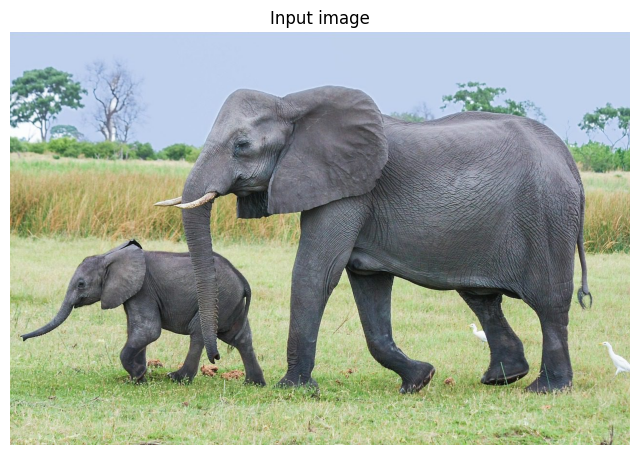

In [11]:
# Define the URL of the image to be downloaded.
url = "https://learnopencv.com/wp-content/uploads/2025/06/elephants.jpg"
# Download the image from the URL and store the content as bytes.
# A timeout of 15 seconds is set for the request.

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://google.com"  # sometimes required
}

img_bytes = requests.get(url, headers=headers, timeout=15).content
# Open the image from the downloaded bytes using Pillow.
# io.BytesIO treats the bytes like a file.
# .convert("RGB") ensures the image is in RGB format (3 color channels).
img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
# Display the loaded image using the previously defined display_image function.
# The title "Input image" is provided for the plot.
display_image(img, title="Input image")

#### Detect Objects and display results

#### Inference

In [18]:
def inference(model, msgs):
    text_prompt = processor.apply_chat_template(
        msgs,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(msgs)

    inputs = processor(
        text=[text_prompt],
        images= image_inputs,
        videos= video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generate_ids = model.generate(
            **inputs,
            max_new_tokens=1000
        )

    output = processor.batch_decode(
        generate_ids[:,inputs.input_ids.shape[-1]:],
        skip_special_token=False
    )[0]

    print(f"Raw output {output}")

    bounding_box = extract_json(output)

    print(f"JSON output : {bounding_box}")

    pprint.pprint(bounding_box, indent=4)

    return bounding_box

In [16]:
bounding_box = extract_json('```json\n[\n\t{"bbox_2d": [298, 107, 1213, 745], "label": "elephants"},\n\t{"bbox_2d": [22, 422, 536, 724], "label": "elephants"}\n]\n```<|im_end|>')
pprint.pprint(bounding_box, indent=4)

[   {'bbox_2d': [298, 107, 1213, 745], 'label': 'elephants'},
    {'bbox_2d': [22, 422, 536, 724], 'label': 'elephants'}]


Raw output ```json
[
	{"bbox_2d": [20, 423, 532, 726], "label": "animal"},
	{"bbox_2d": [298, 110, 1210, 740], "label": "animal"}
]
```<|im_end|>
JSON output : [{'bbox_2d': [20, 423, 532, 726], 'label': 'animal'}, {'bbox_2d': [298, 110, 1210, 740], 'label': 'animal'}]
[   {'bbox_2d': [20, 423, 532, 726], 'label': 'animal'},
    {'bbox_2d': [298, 110, 1210, 740], 'label': 'animal'}]


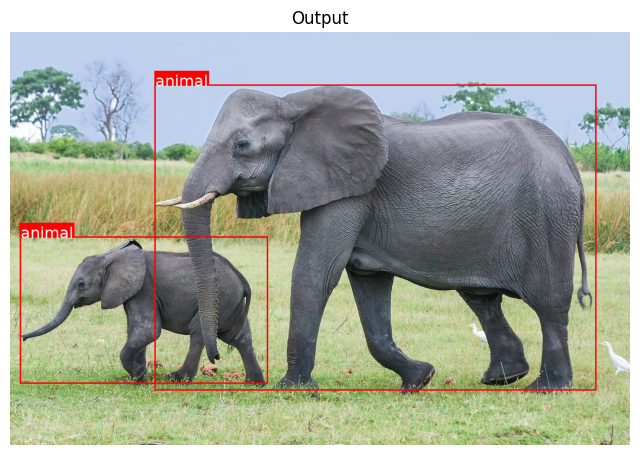

In [20]:
msgs = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": (
                    "You are an object detector. The format of your output should be a valid JSON object "
                    "{'bbox_2d': [x1, y1, x2, y2], 'label': 'class'} where class is the name of the class you are detecting."
                )
            }
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {
                "type": "text",
                "text": "Outline all the animals"
            }
        ],
    }
]

# Run inference
bounding_boxes = inference(model, msgs)

# Draw the bounding boxes on the image
img_out = draw_bboxes(img.copy(), bounding_boxes)

# Display the output
display_image(img_out, title="Output")